# Reprogramming Case 01: Cardiac Inhibition Analysis with Navigo

This notebook reproduces the cardiac reprogramming inhibition analysis described in the Navigo study. The biological question is why fibroblast-to-cardiomyocyte conversion remains inefficient even with cardiac TF programs.

Training note: **`checkpoint_cardiac_repro` is trained using fibroblasts and cardiomyocytes together**, so the learned dynamics focus on fibroblast-to-cardiac state transitions.

Biological rationale used here:
- We model fibroblasts as the source state and cardiomyocytes as the desired fate.
- We simulate regulator-level perturbations in silico and track downstream transcriptomic response.
- We reconstruct a three-layer regulatory cascade linking cardiac TFs, pro-fibrotic intermediates, and cardiac structural genes.
- We use this network to interpret antagonistic mechanisms (pro-fibrotic activation that counteracts cardiac maturation) and generate inhibition hypotheses.

Import packages and set deterministic seeds for reproducible biological screening results.

In [1]:
import os
import sys
from pathlib import Path

import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import torch

plt.rcParams['font.style'] = 'italic'
plt.rcParams['figure.dpi'] = 120
np.random.seed(0)
torch.manual_seed(0)


Locate repository resources and load Navigo APIs.

Biological context: `checkpoint_cardiac_repro.pth` is the fibroblast+cardiomyocyte trained model, and the fibroblast atlas provides the baseline cellular state from which perturbation responses are simulated.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'docs' / 'tutorials').exists() and (p / 'navigo').exists():
            return p
    raise RuntimeError(f'Could not locate repository root from {start}')


cwd = Path.cwd().resolve()
repo_root = find_repo_root(cwd)
tutorials_root = repo_root / 'docs' / 'tutorials'
notebook_dir = tutorials_root / 'notebooks' / 'reprogramming_section'
data_shared_dir = repo_root / 'data' / 'shared'
case_output_root = tutorials_root / 'outputs' / 'reprogramming_cardiac_inhibition'

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print('Repository root       :', repo_root)
print('Tutorial root         :', tutorials_root.relative_to(repo_root))
print('Notebook dir          :', notebook_dir.relative_to(repo_root))
print('Case output root      :', case_output_root.relative_to(repo_root))
print('Shared data dir       :', data_shared_dir.relative_to(repo_root))

from navigo import run_perturbation_inference


Repository root       : /workspace/fuchenghao/Navigo_unified_repo
Tutorial root         : docs/tutorials
Notebook dir          : docs/tutorials/notebooks/reprogramming_section
Case output root      : docs/tutorials/outputs/reprogramming_cardiac_inhibition
Shared data dir       : data/shared


Define data inputs and organized output directories for the cardiac inhibition case.

In [3]:
CHECKPOINT_PATH = repo_root / 'checkpoints' / 'reprogramming' / 'cardiac_reprogramming_checkpoint.pth'
DATA_PATH = data_shared_dir / 'mouse_heart_fibroblasts.h5ad'
TARGET_LIST_PATH = data_shared_dir / 'cardiomyocyte_inhibition_targets.csv'

INFERRED_DIR = case_output_root / '01_inference_csv'
FIGURE_DIR = case_output_root / '02_figures'
SUMMARY_DIR = case_output_root / '03_summaries'

INFERRED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

required = {
    'checkpoint': CHECKPOINT_PATH,
    'dataset_h5ad': DATA_PATH,
    'target_list_csv': TARGET_LIST_PATH,
}

missing = [f'{k}: {v}' for k, v in required.items() if not v.exists()]
if missing:
    print('Missing required resources:')
    for m in missing:
        print(' -', m)
    raise FileNotFoundError('Required resources are missing.')

print('All required resources found.')


All required resources found.


## Run perturbation inference (paper-aligned setup)

For each candidate regulator, Navigo predicts fibroblast expression shifts after intervention.
To match the manuscript evaluation logic, we interpret perturbation quality by directional consistency with expected fibroblast-to-cardiomyocyte transitions (Methods, Eq. 30-32).

In [4]:
inference_summary = run_perturbation_inference(
    data_path=DATA_PATH,
    checkpoint_path=CHECKPOINT_PATH,
    target_list_path=TARGET_LIST_PATH,
    output_dir=INFERRED_DIR,
    fibro_cell_type='Fibroblasts',
    input_dim=7804,
    hidden_1=5012,
    hidden_2=5012,
    flow_num_steps=100,
    simulation_steps=10,
    knockout_scale=3.0,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    strict_target_presence=False,
)

print(json.dumps(inference_summary, indent=2))


Perturbation inference:   0%|          | 0/57 [00:00<?, ?it/s]

Perturbation inference:   2%|▏         | 1/57 [00:19<18:22, 19.68s/it]

Perturbation inference:   4%|▎         | 2/57 [00:47<22:27, 24.49s/it]

Perturbation inference:   5%|▌         | 3/57 [01:18<24:50, 27.60s/it]

Perturbation inference:   7%|▋         | 4/57 [01:42<22:52, 25.89s/it]

...

Perturbation inference:  96%|█████████▋| 55/57 [22:29<00:50, 25.31s/it]

Perturbation inference:  98%|█████████▊| 56/57 [22:52<00:24, 24.77s/it]

Perturbation inference: 100%|██████████| 57/57 [23:13<00:00, 23.53s/it]

Perturbation inference: 100%|██████████| 57/57 [23:13<00:00, 24.45s/it]

{
  "data_path": "/workspace/fuchenghao/Navigo_unified_repo/data/shared/mouse_heart_fibroblasts.h5ad",
  "checkpoint_path": "/workspace/fuchenghao/Navigo_unified_repo/checkpoints/reprogramming/cardiac_reprogramming_checkpoint.pth",
  "target_list_path": "/workspace/fuchenghao/Navigo_unified_repo/data/shared/cardiomyocyte_inhibition_targets.csv",
  "output_dir": "/workspace/fuchenghao/Navigo_unified_repo/docs/tutorials/outputs/reprogramming_cardiac_inhibition/01_inference_csv",
  "device": "cpu",
  "num_cells_fibro": 6711,
  "num_targets": 57,
  "num_outputs": 57,
  "missing_targets_unique": [],
  "flow_num_steps": 100,
  "simulation_steps": 10,
  "knockout_scale": 3.0,
  "elapsed_sec": 1497.317822933197
}


## Build a mechanistic three-layer network

Layers used for interpretation:
- **Layer 1 (cardiac TFs)**: candidate drivers such as Gata4/Mef2c/Esrrg/Hif1a
- **Layer 2 (pro-fibrotic genes)**: inferred intermediates that can counteract conversion
- **Layer 3 (cardiac development genes)**: terminal readouts linked to cardiomyocyte identity

Edge color shows inferred effect direction under perturbation: red = activation, blue = suppression.

In [5]:
TOP_TFS = ['Gata4', 'Mef2c', 'Esrrg', 'Hif1a']
FIBRO_GENES = ['Meox2', 'Igf1', 'Col3a1', 'Hmga2', 'Klf12', 'Bnc2']
CARDI_GENES = ['Sgcd', 'Cacna1c', 'Tgfbr3', 'Nr3c1', 'Adamts9', 'Dlc1']


def collect_edges(folder):
    edges, colors, widths, rows = [], [], [], []

    for tf in TOP_TFS:
        tf_file = folder / f'{tf}.csv'
        if not tf_file.exists():
            continue
        df = pd.read_csv(tf_file)
        for g in FIBRO_GENES:
            hit = df[df['gene_name'] == g]
            if hit.empty:
                continue
            v = float(hit['total_change'].iloc[0])
            edges.append((tf, g))
            colors.append('red' if v > 0 else 'blue')
            widths.append(abs(v) * 1000)
            rows.append({'source': tf, 'target': g, 'layer': 'TF->Fibro', 'total_change': v})

    for f in FIBRO_GENES:
        f_file = folder / f'{f}.csv'
        if not f_file.exists():
            continue
        df = pd.read_csv(f_file)
        for g in CARDI_GENES:
            hit = df[df['gene_name'] == g]
            if hit.empty:
                continue
            v = float(hit['total_change'].iloc[0])
            edges.append((f, g))
            colors.append('red' if v > 0 else 'blue')
            widths.append(abs(v) * 1000)
            rows.append({'source': f, 'target': g, 'layer': 'Fibro->Cardio', 'total_change': v})

    return edges, colors, widths, pd.DataFrame(rows)


def plot_three_layer_network(edges, edge_colors, edge_weights, out_pdf):
    G = nx.DiGraph()
    G.add_nodes_from(TOP_TFS, node_type='TF')
    G.add_nodes_from(FIBRO_GENES, node_type='Fibro')
    G.add_nodes_from(CARDI_GENES, node_type='Cardi')
    G.add_edges_from(edges)

    pos = {}
    tf_x = np.linspace(0, 1, len(TOP_TFS))
    fib_x = np.linspace(0, 1, len(FIBRO_GENES))
    car_x = np.linspace(0, 1, len(CARDI_GENES))

    for i, n in enumerate(TOP_TFS):
        pos[n] = (tf_x[i], 0.8)
    for i, n in enumerate(FIBRO_GENES):
        pos[n] = (fib_x[i], 0.5)
    for i, n in enumerate(CARDI_GENES):
        pos[n] = (car_x[i], 0.2)

    fig = plt.figure(figsize=(12, 10))
    tab20 = plt.cm.tab20.colors

    nx.draw_networkx_nodes(G, pos, nodelist=TOP_TFS, node_color=[tab20[5]], node_size=10000, node_shape='o', alpha=0.3)
    nx.draw_networkx_nodes(G, pos, nodelist=FIBRO_GENES, node_color=[tab20[11]], node_size=7000, node_shape='o', alpha=0.3)
    nx.draw_networkx_nodes(G, pos, nodelist=CARDI_GENES, node_color=[tab20[9]], node_size=9000, node_shape='o', alpha=0.3)

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=edges,
        edge_color=edge_colors,
        width=edge_weights,
        arrows=True,
        arrowsize=30,
        arrowstyle='->',
        min_source_margin=40,
        min_target_margin=40,
    )

    nx.draw_networkx_labels(G, pos, font_size=26)

    plt.xlim(-0.1, 1.1)
    plt.ylim(0, 1)
    plt.axis('off')
    plt.tight_layout()

    fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
    plt.show()


Total plotted edges: 60


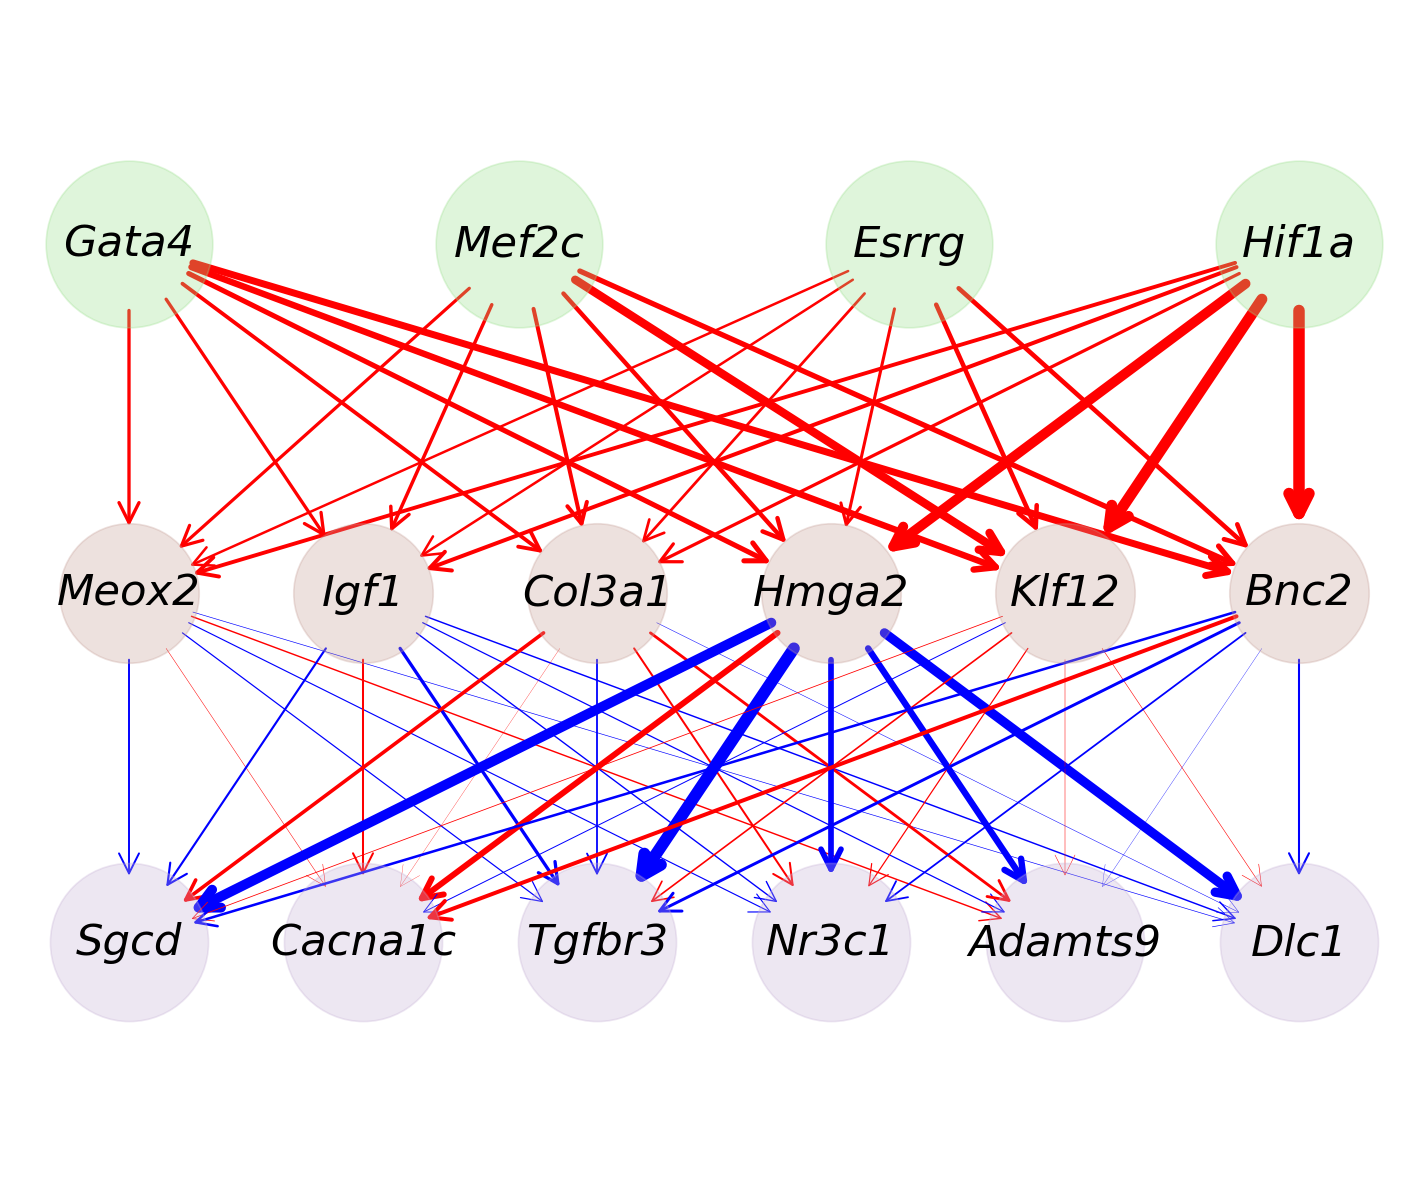

Saved figure PDF: /workspace/fuchenghao/Navigo_unified_repo/docs/tutorials/outputs/reprogramming_cardiac_inhibition/02_figures/01_three_layer_cardiac_reprogramming_network.pdf


In [6]:
edges, edge_colors, edge_weights, edge_df = collect_edges(INFERRED_DIR)
print('Total plotted edges:', len(edges))

out_pdf = FIGURE_DIR / '01_three_layer_cardiac_reprogramming_network.pdf'
plot_three_layer_network(edges, edge_colors, edge_weights, out_pdf)

print('Saved figure PDF:', out_pdf)


## Biological readout summary

We export full and ranked edge tables so strong positive and negative links can be prioritized for experimental follow-up, including tests of whether inhibiting pro-fibrotic nodes improves cardiac conversion efficiency.

In [7]:
if edge_df.empty:
    raise ValueError('No edges found from inferred outputs.')

edge_table_path = SUMMARY_DIR / '01_cardiac_reprogramming_edges_all.csv'
positive_path = SUMMARY_DIR / '01_top_positive_edges.csv'
negative_path = SUMMARY_DIR / '01_top_negative_edges.csv'

edge_df.to_csv(edge_table_path, index=False)
edge_df.sort_values('total_change', ascending=False).head(12).to_csv(positive_path, index=False)
edge_df.sort_values('total_change', ascending=True).head(12).to_csv(negative_path, index=False)


print('Saved summary tables:')
print(' -', edge_table_path)
print(' -', positive_path)
print(' -', negative_path)


Saved summary tables:
 - /workspace/fuchenghao/Navigo_unified_repo/docs/tutorials/outputs/reprogramming_cardiac_inhibition/03_summaries/01_cardiac_reprogramming_edges_all.csv
 - /workspace/fuchenghao/Navigo_unified_repo/docs/tutorials/outputs/reprogramming_cardiac_inhibition/03_summaries/01_top_positive_edges.csv
 - /workspace/fuchenghao/Navigo_unified_repo/docs/tutorials/outputs/reprogramming_cardiac_inhibition/03_summaries/01_top_negative_edges.csv


In [8]:
print('PDF figure:', FIGURE_DIR / '01_three_layer_cardiac_reprogramming_network.pdf')

PDF figure: /workspace/fuchenghao/Navigo_unified_repo/docs/tutorials/outputs/reprogramming_cardiac_inhibition/02_figures/01_three_layer_cardiac_reprogramming_network.pdf
